csv dosyalarını okuma

In [1]:
import pandas as pd
import numpy as np
import os
path= r"C:\\Users\\umuty\Desktop\\Tipta_YZ_Gercek_Dunya_Projeleri\\aptos_dataset\\" #dosya yolunu belirttik
df= pd.read_csv(path+"train_1.csv",sep=',') #csv dosyasında da virgülle ayrıldığı için sep=',' dedik
df.head() #ilk 5 satırı gösterir

,id_code,diagnosis
0,1ae8c165fd53,2
1,1b329a127307,1
2,1b32e1d775ea,4
3,1b3647865779,0
4,1b398c0494d1,0


<Axes: >

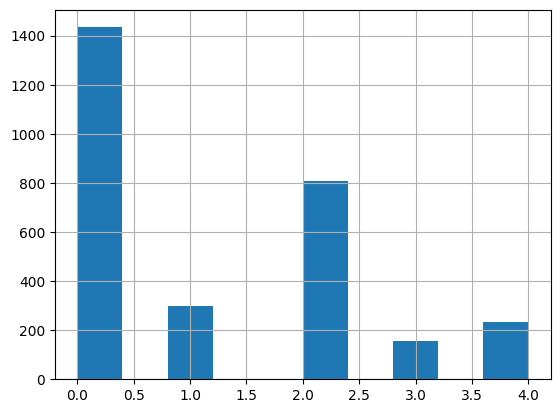

In [2]:
df["diagnosis"].hist() #histogram çizdirir

In [3]:
df["diagnosis"].value_counts() #her bir sınıftan kaç tane olduğunu gösterir
##gerektiginde sort_values ile sıralama yapılabilir (veri seti ve csv dosyası aynı düzende degilse)

diagnosis
0    1434
2     808
1     300
4     234
3     154
Name: count, dtype: int64

Görüntüleri Okuma

In [4]:
import os
files = os.listdir(path+"train_images") #dosya yolundaki dosyaları listeler
files
len(files) #dosya sayısını verir

2930

In [5]:
import cv2
img_list=[]
for i in files:
    image= cv2.imread(path+"train_images/"+i) #resmi okur
    image = cv2.resize(image,(400,400)) #resmi boyutlandırır
    image= cv2.cvtColor(image, cv2.COLOR_BGR2RGB) #renk dönüşümü yapar cunku oopencv resmi bgr olarak okur
    img_list.append(image) #resmi listeye ekler

In [6]:
len(img_list) #resim sayısını verir

2930

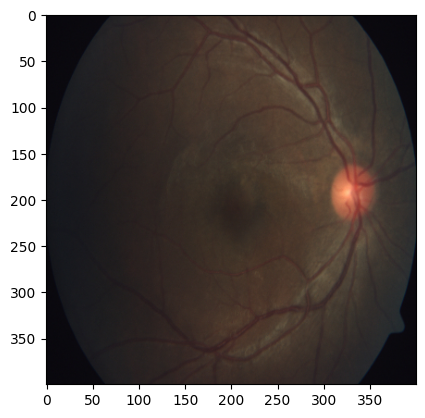

In [7]:
import matplotlib.pyplot as plt
plt.imshow(img_list[87]) #resmi gösterir

Ön işleme Adımları (Threshold-GaussianBlur)   BU KISIMLARI YAPMAK MODELİN PEROFRMANSINI ÇOK DAHA İYİ SEVİYEYE GETİRECEKTİR

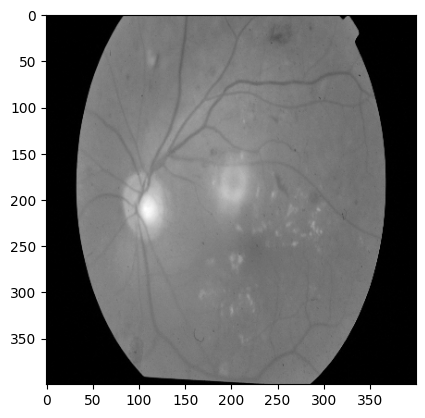

In [8]:
#thresholdu kullanmamızın sebebi resimlerdeki farklı boyutlardaki siyahlıkları aynı seviyeye getirmek
kopya = img_list[23].copy()
kopya = cv2.cvtColor(kopya, cv2.COLOR_BGR2GRAY) #threshold uygulamak için resmi griye çevirir
plt.imshow(kopya,cmap='gray') #resmi gösterir

In [9]:
kopya.shape

(400, 400)

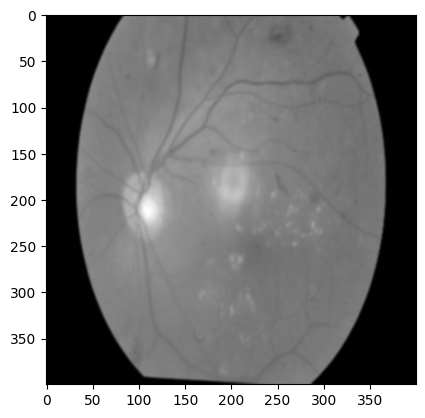

In [10]:
blur = cv2.GaussianBlur(kopya,(5,5),0) #resmi blurlar
plt.imshow(blur,cmap='gray') #resmi gösterir

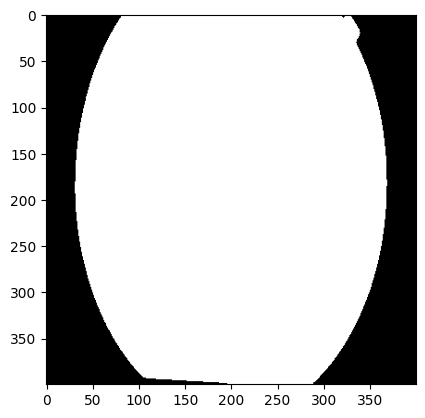

In [11]:
thresh = cv2.threshold(blur,10,255,cv2.THRESH_BINARY)[1] #threshold uygular (10 un altındaki pikselleri siyah yapar)
plt.imshow(thresh,cmap='gray') #resmi gösterir  

Kontur Bulma - Görüntüyü Kırpma

In [12]:
countour= cv2.findContours(thresh.copy(),cv2.RETR_EXTERNAL,cv2.CHAIN_APPROX_SIMPLE) #resimdeki konturları bulur
countour

((array([[[ 82,   0]],
  
         [[ 82,   1]],
  
         [[ 81,   2]],
  
         [[ 81,   3]],
  
         [[ 79,   5]],
  
         [[ 79,   6]],
  
         [[ 78,   7]],
  
         [[ 78,   8]],
  
         [[ 76,  10]],
  
         [[ 76,  11]],
  
         [[ 74,  13]],
  
         [[ 74,  14]],
  
         [[ 73,  15]],
  
         [[ 73,  16]],
  
         [[ 72,  17]],
  
         [[ 72,  18]],
  
         [[ 70,  20]],
  
         [[ 70,  21]],
  
         [[ 69,  22]],
  
         [[ 69,  23]],
  
         [[ 68,  24]],
  
         [[ 68,  25]],
  
         [[ 67,  26]],
  
         [[ 67,  27]],
  
         [[ 66,  28]],
  
         [[ 66,  29]],
  
         [[ 65,  30]],
  
         [[ 65,  31]],
  
         [[ 64,  32]],
  
         [[ 64,  33]],
  
         [[ 63,  34]],
  
         [[ 63,  35]],
  
         [[ 62,  36]],
  
         [[ 62,  38]],
  
         [[ 61,  39]],
  
         [[ 61,  40]],
  
         [[ 60,  41]],
  
         [[ 60,  42]],
  
         [[ 

In [13]:
countour=countour[0][0] #konturları verir hiyerarsi sirasini atar

In [14]:
countour.shape

(411, 1, 2)

In [15]:
countour = countour[:,0,:] #ortadaki 12 degerrini elemis olduk
countour.shape

(411, 2)

In [16]:
sag = tuple(countour[countour[:,0].argmax()]) #x koordinatındaki en büyük değeri verir (goruntudeki en sag degeri verir)
sol = tuple(countour[countour[:,0].argmin()]) #x koordinatındaki en küçük değeri verir (goruntudeki en sol degeri verir)
alt = tuple(countour[countour[:,1].argmax()]) #y koordinatındaki en büyük değeri verir (goruntudeki en alt degeri verir)
ust = tuple(countour[countour[:,1].argmin()]) #y koordinatındaki en küçük değeri verir (goruntudeki en üst degeri verir)

sol,sag,alt,ust

((np.int32(31), np.int32(181)),
 (np.int32(368), np.int32(185)),
 (np.int32(196), np.int32(399)),
 (np.int32(82), np.int32(0)))

In [17]:
x1= sol[0] #burda kırpılacak bölgeleri ayarlıyoruz
y1= ust[1]
x2=sag[0]
y2=alt[1]
x1,y1,x2,y2

(np.int32(31), np.int32(0), np.int32(368), np.int32(399))

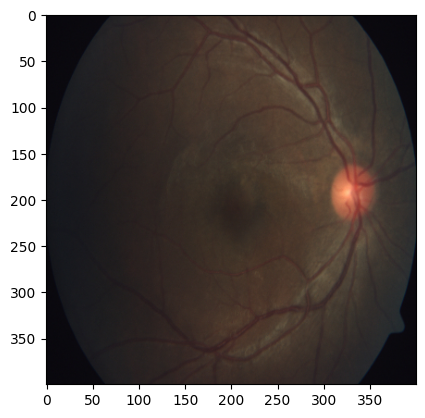

In [18]:
orijinal = img_list[87].copy()
plt.imshow(orijinal)

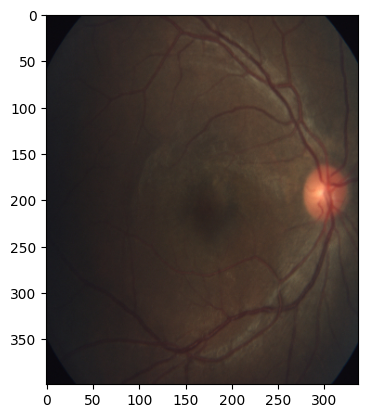

In [19]:
crop_ilk=orijinal[y1:y2,x1:x2]
plt.imshow(crop_ilk)

In [20]:
crop_ilk.shape   #kırpma yapıldıkan sonra boyut da değişi

(399, 337, 3)

(400, 400, 3)

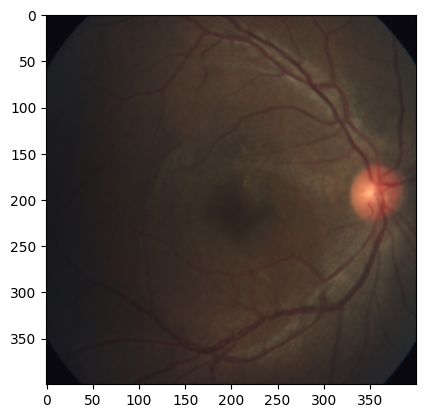

In [21]:
crop_ilk = cv2.resize(crop_ilk,(400,400)) #tekrardan 400 400 e boyutlandırdık
plt.imshow(crop_ilk)
crop_ilk.shape

In [22]:
x = int(x2-x1)*4//100  #burdaki degerleri kursda kendisi veriyor
y= int(y2-y1)*5//100
x,y

(13, 19)

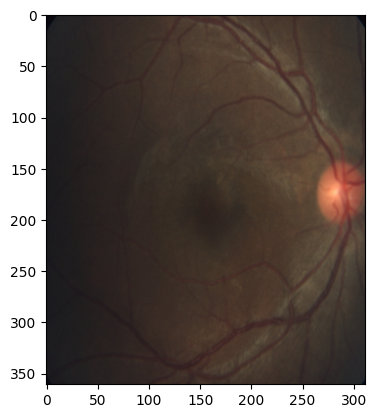

In [23]:
crop_son=orijinal[y1+y:y2-y,x1+x:x2-x]  ##bu işlemi yaptıktan sonra kenarlardan ve koselerdeki siyahlıkları biraz daha temizlimiş olduk
plt.imshow(crop_son)

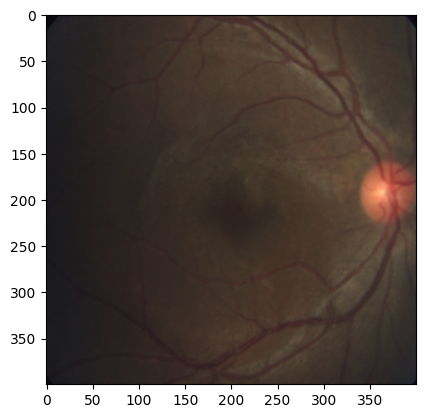

In [24]:
crop_son = cv2.resize(crop_son,(400,400))  ##tekrar 400 400 e boyutlandırdık
plt.imshow(crop_son)

CLAHE - Konstrat Limitli Adaptif Histogram Eşitleme

In [25]:
lab = cv2.cvtColor(crop_son,cv2.COLOR_BGR2LAB)  ##renk uzayını değiştirdik lab yaptık (L:lightness A:green-red B:blue-yellow)
lab.shape

(400, 400, 3)

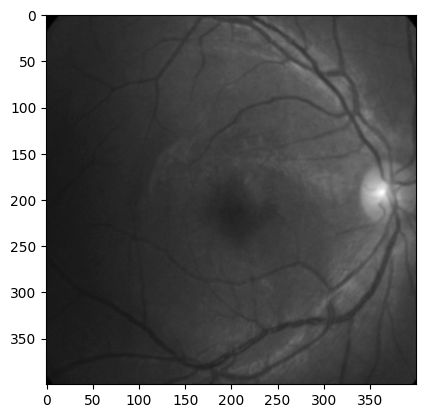

In [26]:
l,a,b = cv2.split(lab) #bize parlaklık lazım oldugu icin ayırma yapıyoruz
plt.imshow(l,cmap='gray')

In [27]:
l.shape  ##iki boyutlu
duz = l.flatten() #histogram için düzleştirme yapıyoruz
duz.shape

(160000,)

C:\Users\umuty\AppData\Local\Temp\ipykernel_8684\4117846272.py:1: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.hist(duz,25,[0,256],color="r")


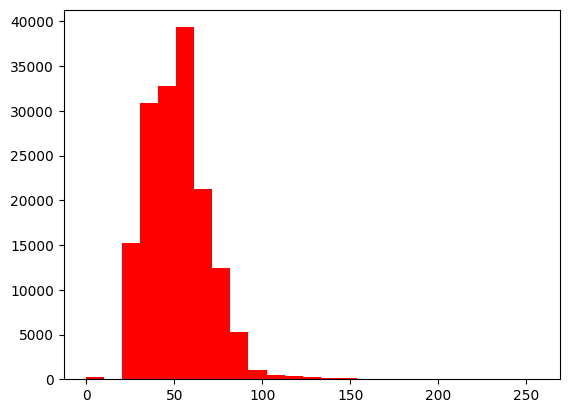

In [28]:
plt.hist(duz,25,[0,256],color="r")
plt.show()

In [29]:
clahe = cv2.createCLAHE(clipLimit=7.0,tileGridSize=(8,8)) ##histogram eşitleme yapar CLAHE
cl = clahe.apply(l)

C:\Users\umuty\AppData\Local\Temp\ipykernel_8684\1659279696.py:1: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.hist(cl.flatten(),25,[0,256],color="r")  #goruntunun piksel degerlerini birbirine yakınlastırarak aradaki uçurumu azaltır


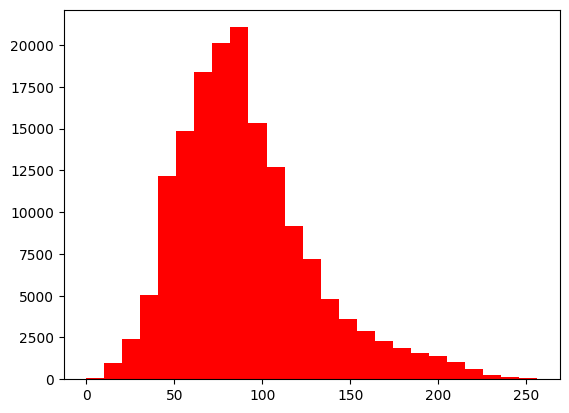

In [30]:
plt.hist(cl.flatten(),25,[0,256],color="r")  #goruntunun piksel degerlerini birbirine yakınlastırarak aradaki uçurumu azaltır
plt.show()

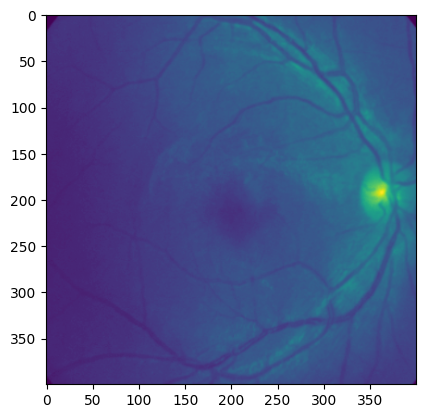

In [31]:
plt.imshow(l)

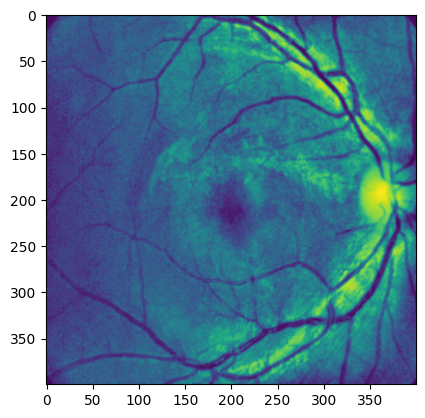

In [32]:
plt.imshow(cl)

En son cl haliyle a,b halini birleştirip rgb ye çeviriyoruz

In [33]:
limg = cv2.merge((cl,a,b))

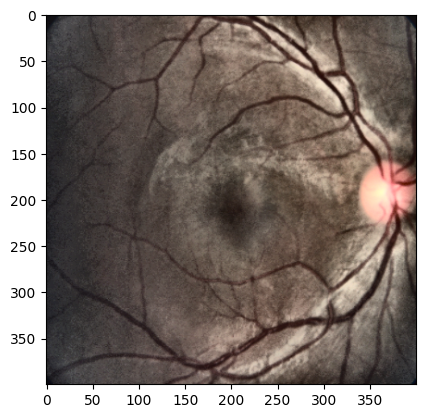

In [34]:
son = cv2.cvtColor(limg,cv2.COLOR_LAB2BGR)  ##tekrar renk uzayını değiştiriyoruz
plt.imshow(son)

Görüntünün üzerinde kumlanmalar oluştu bunu çözmek için gerekli ön işleme adımlarını kullanacağız

Median Blur

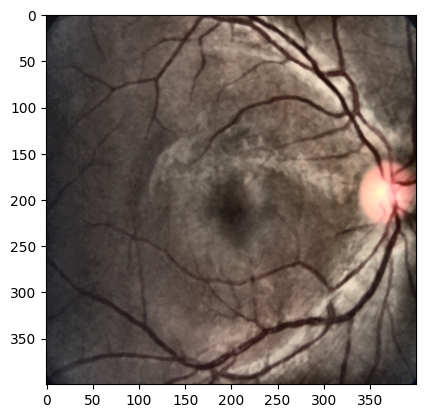

In [35]:
med_son = cv2.medianBlur(son,3)
plt.imshow(med_son)

Şimdi ise göz içindeki kanamaları belirginleştirmek için bir maske uygulayacaz

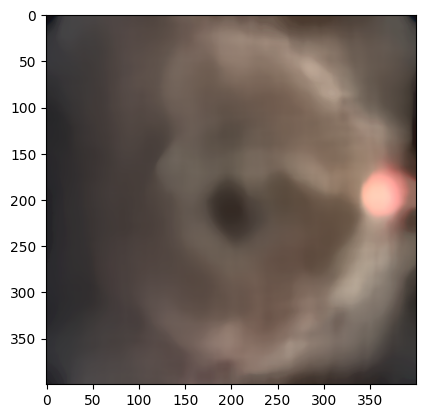

In [36]:
arka_plan = cv2.medianBlur(son,37)  ##arka planı bulmak için median blur uyguluyoruz
plt.imshow(arka_plan)

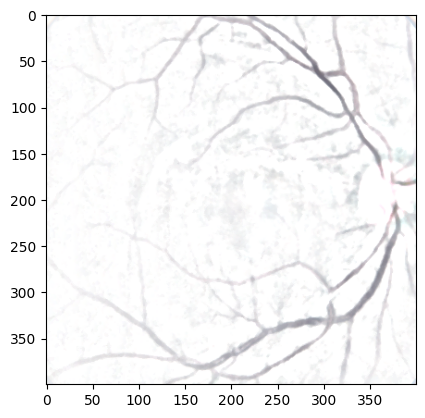

In [37]:
maske = cv2.addWeighted(med_son,1,arka_plan,-1,255)
plt.imshow(maske)

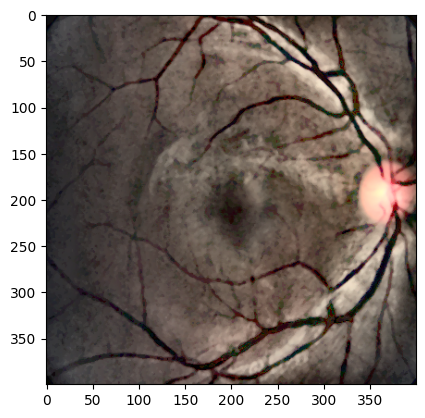

In [38]:
son_img = cv2.bitwise_and(maske,med_son)    ##boylelikle damarları ve kanamaları daha belirgin hale getirmiş olduk
plt.imshow(son_img)

Bütün ön işleme kodlarını toplama

In [39]:
img_list=[]
for i in (files):
    image = cv2.imread(path+"train_images/"+i)
    image = cv2.resize(image,(400,400))
    image = cv2.cvtColor(image,cv2.COLOR_BGR2RGB)
    kopya = image.copy()
    kopya = cv2.cvtColor(kopya,cv2.COLOR_BGR2GRAY)
    blur = cv2.GaussianBlur(kopya,(5,5),0)
    thresh = cv2.threshold(blur,10,255,cv2.THRESH_BINARY)[1]
    countour = cv2.findContours(thresh.copy(),cv2.RETR_EXTERNAL,cv2.CHAIN_APPROX_SIMPLE)
    countour = countour[0][0]
    countour = countour[:,0,:]
    x1= tuple(countour[countour[:,0].argmin()])[0]
    y1= tuple(countour[countour[:,1].argmin()])[1]
    x2= tuple(countour[countour[:,0].argmax()])[0]
    y2= tuple(countour[countour[:,1].argmax()])[1]
    x = int(x2-x1)*4//100
    y= int(y2-y1)*5//100
    kopya2= image.copy()
    if x2-x1>100 and y2-y1>100:
        kopya2 = kopya2[y1+y:y2-y,x1+x:x2-x]
        kopya2 = cv2.resize(kopya2,(400,400))
    lab= cv2.cvtColor(kopya2,cv2.COLOR_BGR2LAB)
    l,a,b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=7.0,tileGridSize=(8,8))
    cl = clahe.apply(l)
    limg = cv2.merge((cl,a,b))
    son = cv2.cvtColor(limg,cv2.COLOR_LAB2BGR)
    med_son = cv2.medianBlur(son,3)
    arka_plan = cv2.medianBlur(son,37)
    maske = cv2.addWeighted(med_son,1,arka_plan,-1,255)
    son_img = cv2.bitwise_and(maske,med_son)
    img_list.append(son_img)

Toplu Görselleştirme Yapalım

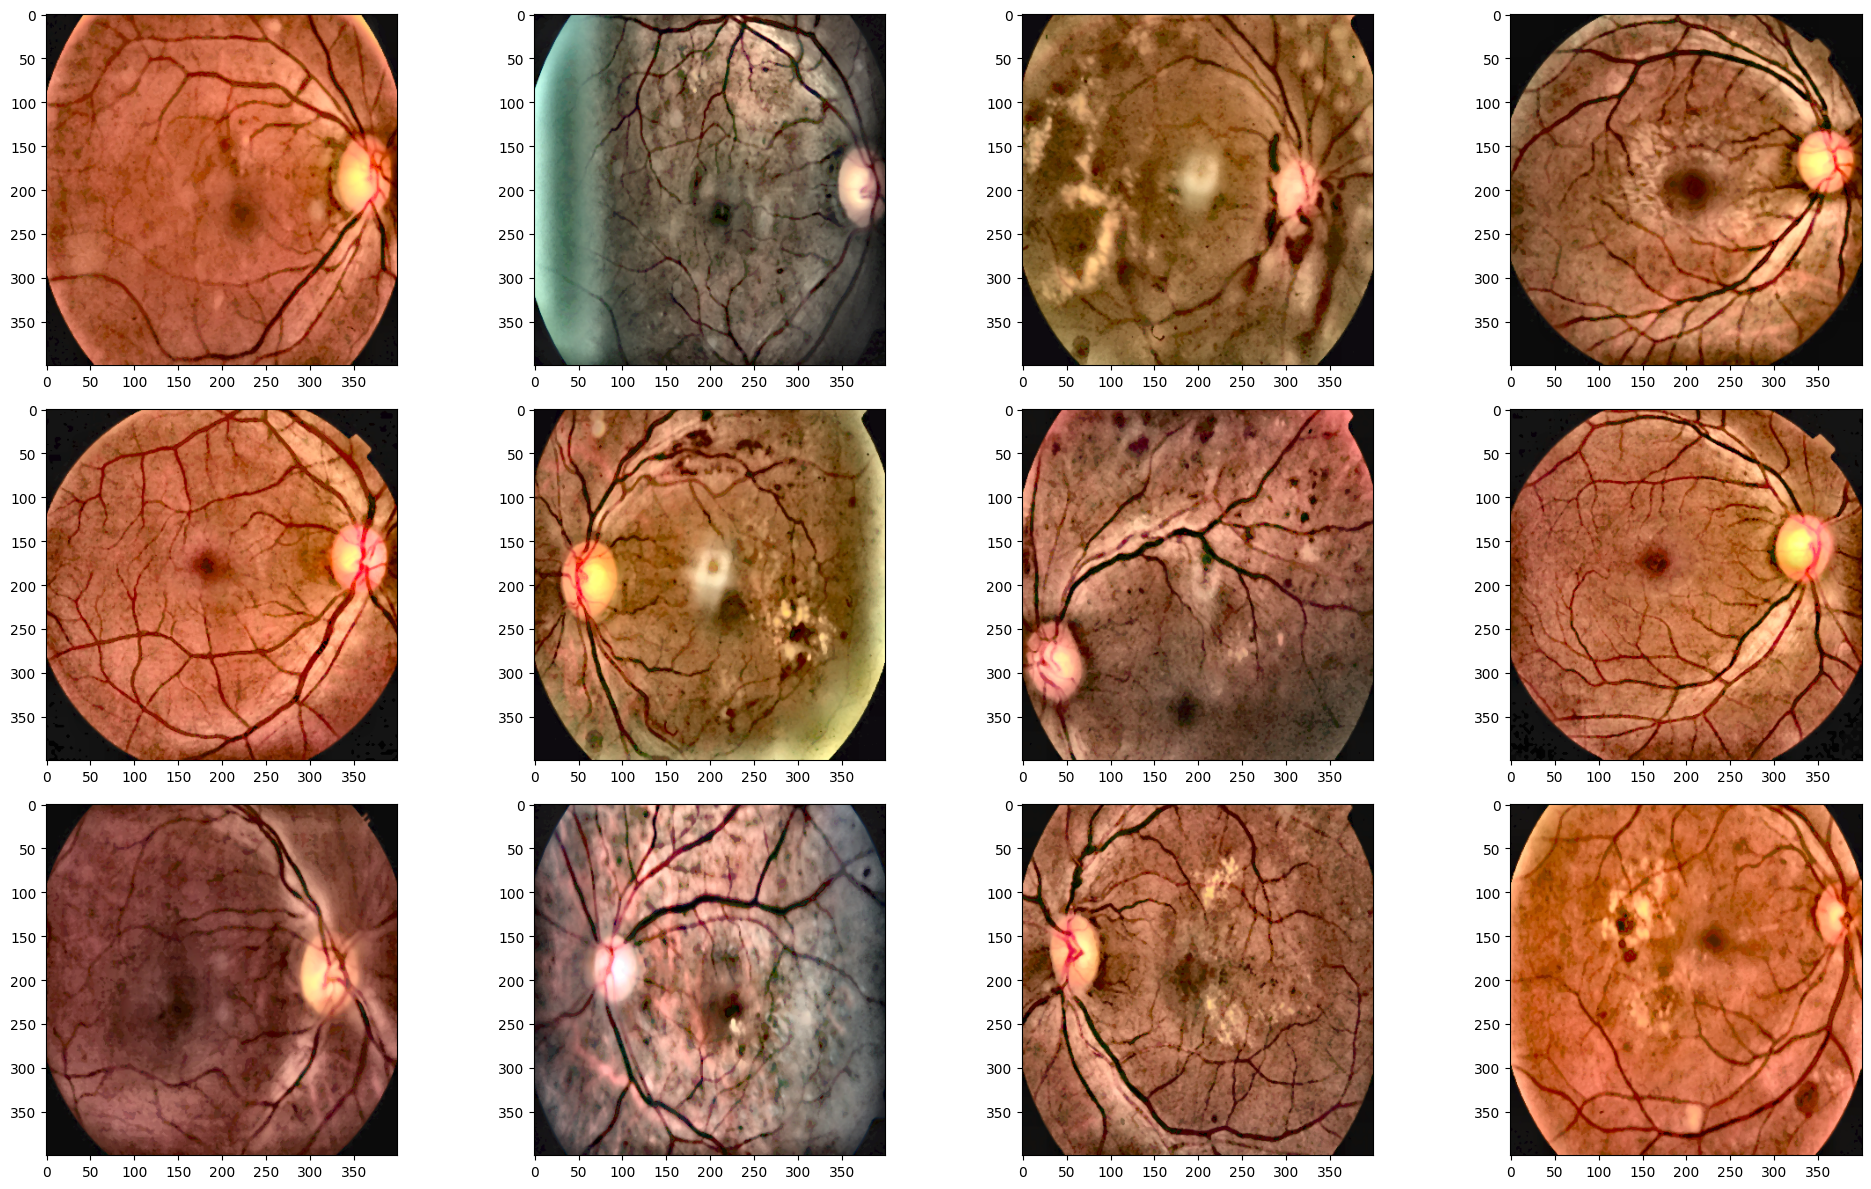

In [40]:
fig = plt.figure(figsize=(20,12))
for i in range(12):
    img = img_list[i]
    fig.add_subplot(3,4,i+1)
    plt.imshow(img)
plt.tight_layout()

Sınıflandırma Verisi için ön işleme

In [41]:
df["diagnosis"]

0       2
1       1
2       4
3       0
4       0
       ..
2925    0
2926    0
2927    0
2928    0
2929    0
Name: diagnosis, Length: 2930, dtype: int64

One hot encoding yapıyoruz

In [42]:
y_train = pd.get_dummies(df["diagnosis"]).values ##one hot encoding yapıyoruz


In [43]:
y_train

array([[False, False,  True, False, False],
       [False,  True, False, False, False],
       [False, False, False, False,  True],
       ...,
       [ True, False, False, False, False],
       [ True, False, False, False, False],
       [ True, False, False, False, False]], shape=(2930, 5))

In [44]:
df["diagnosis"][0]

np.int64(2)

In [45]:
y_train[0]

array([False, False,  True, False, False])

In [46]:
import numpy as np
y_train_son = np.ones(y_train.shape,dtype="uint8")

In [47]:
y_train_son

array([[1, 1, 1, 1, 1],
       [1, 1, 1, 1, 1],
       [1, 1, 1, 1, 1],
       ...,
       [1, 1, 1, 1, 1],
       [1, 1, 1, 1, 1],
       [1, 1, 1, 1, 1]], shape=(2930, 5), dtype=uint8)

In [48]:
y_train_son[:,4] = y_train[:,4]

In [49]:
y_train_son

array([[1, 1, 1, 1, 0],
       [1, 1, 1, 1, 0],
       [1, 1, 1, 1, 1],
       ...,
       [1, 1, 1, 1, 0],
       [1, 1, 1, 1, 0],
       [1, 1, 1, 1, 0]], shape=(2930, 5), dtype=uint8)

In [50]:
np.logical_or(0,0) #ikisinden birinin 1 olmasıda bile true döner

np.False_

In [51]:
for i in range(3,-1,-1):
    y_train_son[:,i] = np.logical_or(y_train[:,i],y_train_son[:,i+1])

In [52]:
y_train

array([[False, False,  True, False, False],
       [False,  True, False, False, False],
       [False, False, False, False,  True],
       ...,
       [ True, False, False, False, False],
       [ True, False, False, False, False],
       [ True, False, False, False, False]], shape=(2930, 5))

In [53]:
y_train_son

array([[1, 1, 1, 0, 0],
       [1, 1, 0, 0, 0],
       [1, 1, 1, 1, 1],
       ...,
       [1, 0, 0, 0, 0],
       [1, 0, 0, 0, 0],
       [1, 0, 0, 0, 0]], shape=(2930, 5), dtype=uint8)

Eğitim-Test Verisi Ayırma

In [54]:
x_train = np.array(img_list) #resimleri numpy arrayine çeviriyoruz

In [55]:
x_train.shape

(2930, 400, 400, 3)

In [56]:
y_train_son.shape

(2930, 5)

In [57]:
from sklearn.model_selection import train_test_split
x_train,x_val,y_train,y_val = train_test_split(x_train,y_train_son,test_size=0.15,random_state=2019,shuffle=True)
#random_state bir karısım sayısıdır daha farklı sayılar da var
#shuffle : her zaman true olması daha iyi

In [58]:
x_train.shape,x_val.shape,y_train.shape,y_val.shape

((2490, 400, 400, 3), (440, 400, 400, 3), (2490, 5), (440, 5))

In [66]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
datagen = ImageDataGenerator(horizontal_flip=True,vertical_flip=True,)
#normalde rescale yani normalizasyon da yapılması gerekiyor ama bizim kullanancağımız model EfficientNet bunu kendi yapıyor
#diger cogu modelde bunu yapmamız gerekiyor
data_generator = datagen.flow(x_train,y_train,batch_size=8,seed=2020)

Transfer Learning

Mesela kedi köpeği yüksek doğrulukla sınıflandıran bir model olsun. Bizde nadir bir cilt hastalığını sınıflandırmak istiyoruz ve elimizde de veri az. Bu durumda diğer sınıflandırma modelinin son olasılık hesaplayan katmanını çıkarıp kendi verimize uygun sınıflandırma katmanını yerleştirebiliriz

Kısa Zaman>Az veri>Yuksek Doğruluk

EfficientNetB5 ile Transfer Learning

In [67]:
from tensorflow.keras.applications import EfficientNetB5

In [99]:
# ornek_model = EfficientNetB5()
# ornek_model.summary()

Bizim asıl ilgileceğimiz katman son 3 katman bu katmanları kendimize uygun bir şekilde yazıp ondan sonra modeli eğitime sokacağız

In [71]:
# ornek_model2=EfficientNetB5(include_top=False) ##bizim değiştirip kullanacağımız kısmı kaldırıyoruz
# ornek_model2.summary()

Kendi full-connected katmanımızı oluşturuyoruz

In [68]:
from keras.models import Sequential
from keras import layers

model = Sequential()
model.add(EfficientNetB5(weights="imagenet",include_top=False,input_shape=(400,400,3)))
#EfficientNet de flatten kullanılmıyor onun yerine GlobalAveragePooling2D kullanılıyor
#Parametre sayısı azalıyor, overifti minimalize eder,ortalama en boy degeri alarak veri boyutunu azaltıyor
model.add(layers.GlobalAveragePooling2D())
model.add(layers.Dropout(0.5)) #overfittingi engellemek için dropout ekliyoruz
model.add(layers.Dense(5,activation="sigmoid"))


Sigmoid : normalde iki class varken kullanılır ama 
Bizde 5 class var bunun mantığı şu şekil:
Multi label da ise mesela hem muz hem elma olabilir bunun için sigmoid kullanılır
Multi class da ise sadece bir class olabilir bunun için softmax kullanılır

Biz burda sigmoid kullandık çünkü multi label ile daha iyi sonuclar alınacak


In [69]:
from keras.optimizers import Adam
#sigmoid kullandığımız için binary_crossentropy kullandık
model.compile(loss="binary_crossentropy",optimizer=Adam(learning_rate=0.00005),metrics=["accuracy"]) 

In [70]:
#learning i nasıl otomatik olarak azaltıp arttırma kodu
from keras.callbacks import ReduceLROnPlateau
#eger icine yazılan deger de hep sabit kalırsa ogrenme oranını düşürerek overfittingi engeller
lr = ReduceLROnPlateau(monitor="val_loss",
                       patience=3,
                       verbose=1,mode="auto",
                       factor=0.25, #bizim ogrenme oranımızı 0.25 ile çarpıp yeni ogrenme oranını belirler
                       min_lr=0.000001 ) #en düşük ogrenme oranı


In [71]:
x_train.shape[0]

2490

In [72]:
history = model.fit(data_generator,
                              steps_per_epoch=x_train.shape[0]//8,epochs=10,
                              validation_data=(x_val,y_val),callbacks=[lr])

#modeli ve diğer çıktıları gösterip kaydedenkod
model.save("aptos.h5")
import pickle
with open("aptos_history.json","wb") as f:
    pickle.dump(history.history,f)

import matplotlib.pyplot as plt
plt.plot(history.history["accuracy"])
plt.plot(history.history["val_accuracy"])
plt.title("model accuracy")
plt.ylabel("accuracy")
plt.xlabel("epoch")
plt.legend(["train","validation"],loc="upper left")
plt.show()



Epoch 1/10
311/311 ━━━━━━━━━━━━━━━━━━━━ 2111s 7s/step - accuracy: 0.7627 - loss: 0.4404 - val_accuracy: 0.8045 - val_loss: 0.1598 - learning_rate: 5.0000e-05
Epoch 2/10
  1/311 ━━━━━━━━━━━━━━━━━━━━ 32:23 6s/step - accuracy: 0.8750 - loss: 0.0852

c:\Users\umuty\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\trainers\epoch_iterator.py:107: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


311/311 ━━━━━━━━━━━━━━━━━━━━ 64s 186ms/step - accuracy: 0.8750 - loss: 0.0852 - val_accuracy: 0.8068 - val_loss: 0.1597 - learning_rate: 5.0000e-05
Epoch 3/10
 79/311 ━━━━━━━━━━━━━━━━━━━━ 24:12 6s/step - accuracy: 0.8197 - loss: 0.1566

KeyboardInterrupt: 